# TRAINING CNN FOR PNEUMONIA CLASSIFICATION

I will be using the same model for training models on different datasets (original xrays and transformed xrays); everything stays same besides the path of the dataset to be trained on. I coded this part using online youtube tutorials, a guide from medium, and I also have experience in working with CNNs from before (I knew about the model and training part, just had some issues with balancing the dataset). 

I trained the model locally on my mac, and used claude to see how I could train it on the GPU (which is why I had to download specific version of tensorflow)

## Importing Libraries

This is for loading the dataset, preprocessing where necessary, building the model, training and plotting results.

In [33]:
!pip install tensorflow==2.16.2 tensorflow-metal==1.2.0 scikit-learn matplotlib
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

## Preparing Dataset

These are just the paths to the dataset and where to save the trained model. I kept them as variables so there's just one point needed to change to train on different datasets.

In [34]:
# path to og -> "../chest_xray/xray_og/original_dataset.csv"
# path to transformed -> "../chest_xray/xray_transformed/transform_dataset.csv"
# path to combined -> "../chest_xray/combined_dataset.csv"

# model for og -> "models/original_xray.keras"
# model for transformed -> "models/transformed_xray.keras"
# model for combined -> "models/combined.keras"

PATH_TO_DATA = "../chest_xray/combined_dataset.csv"
SAVE_PATH = "models/combined.keras"

# checking if will train on the mac gpu
# print(tf.__version__) 
print(tf.config.list_physical_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Preparing dataset; the csv is read and images are fetched using the paths. Each image is read, resized and normalised. Processed images and labels are stored.

In [35]:
def load_image(path, label):    #load image and the label from the csv
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img,(224,224))
    img = img/255.0   #normalise img
    return img, label

def make_dataset(df, shuffle=False):
    paths  = df["path"].values
    labels = df["label"].values.astype("float32")
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(32)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

df = pd.read_csv(PATH_TO_DATA)

total_train = df[df["split"] != "test"]
test = df[df["split"] == "test"]

train, val = train_test_split(total_train, test_size=0.2, random_state=42, stratify=total_train["label"])

print("train:", train["label"].value_counts().to_dict())
print("val:  ", val["label"].value_counts().to_dict())
print("test: ", test["label"].value_counts().to_dict())

train_ds = make_dataset(train, shuffle=True)
val_ds = make_dataset(val)
test_ds = make_dataset(test)

train: {1: 3106, 0: 1079}
val:   {1: 777, 0: 270}
test:  {1: 390, 0: 234}


On initial training, the model was barely training and was performing poorly. I then analysed the class balance in the dataset to guage balance of pneumonia and healthy cases.

In [36]:

# Compute class weights
train_labels = train["label"].values
total = len(train_labels)
n_normal    = np.sum(train_labels == 0)
n_pneumonia = np.sum(train_labels == 1)

class_weight = {
    0: total / (2 * n_normal),      # NORMAL
    1: total / (2 * n_pneumonia),   # PNEUMONIA
}

print(class_weight)

{0: 1.9392956441149212, 1: 0.6736960721184804}


## Building Model and Training

I built a simple layer CNN followed by a dense network for classification. This model is very simple; I kept it that way for 2 reasons:
- I trained the model locally, so there was a compute limitation
- the classification task itself is not very complex, and so I thought a more complex model would overfit on the train data and it would be hard to truly study dependencies on underlying medical dataset quality

Ideally I would want to train a segmentation model for multiple things which would be complex, and then test it on different datasets; I think that would be a more conclusive study. However, that would also require more data, labels and far more compute. 

Model details:
- 4 layer CNN with a fully connected classification layer
- each inner layer has ReLU activation with sigmoid used at end for classification
- adam optimiser with 0.0001 lr
- uses cross entropy loss

I have also printed model details


In [37]:
def build_model():

    model = models.Sequential([
        
        # Block 1
        layers.Conv2D(32, (3, 3), padding="same", input_shape=(224, 224, 3)),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(2, 2),

        # Block 2
        layers.Conv2D(64, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(2, 2),

        # Block 3
        layers.Conv2D(128, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(2, 2),

        # Block 4
        layers.Conv2D(256, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(2, 2),

        #classification step
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc"), tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")]
    )
    return model

model = build_model()
model.summary()

/Users/zubair/Desktop/ada_final_project/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_17 (ReLU)                 │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_18 (ReLU)                 │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_19 (ReLU)                 │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_20 (ReLU)                 │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 456,385 (1.74 MB)

 Trainable params: 455,425 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

Trained the model on 20 epochs, and saved the model.

In [38]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(SAVE_PATH, save_best_only=True, monitor="val_auc", mode="max"),
    tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight,
    callbacks = callbacks
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 32s 214ms/step - accuracy: 0.6915 - auc: 0.7705 - loss: 0.5911 - precision: 0.8752 - recall: 0.6816 - val_accuracy: 0.7421 - val_auc: 0.6962 - val_loss: 0.8600 - val_precision: 0.7421 - val_recall: 1.0000
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 27s 204ms/step - accuracy: 0.8213 - auc: 0.8956 - loss: 0.4175 - precision: 0.9300 - recall: 0.8210 - val_accuracy: 0.7421 - val_auc: 0.7284 - val_loss: 1.0812 - val_precision: 0.7421 - val_recall: 1.0000
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 27s 208ms/step - accuracy: 0.8557 - auc: 0.9214 - loss: 0.3604 - precision: 0.9487 - recall: 0.8516 - val_accuracy: 0.5903 - val_auc: 0.7577 - val_loss: 0.9127 - val_precision: 0.8799 - val_recall: 0.5187
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 28s 208ms/step - accuracy: 0.8628 - auc: 0.9288 - loss: 0.3449 - precision: 0.9512 - recall: 0.8593 - val_accuracy: 0.7545 - val_auc: 0.9225 - val_loss: 0.5673 - val_precision: 0.9745 - val_recall: 0.6873
Epoch 5/20
131/131 ━

Plotting the loss curve for train and validation sets

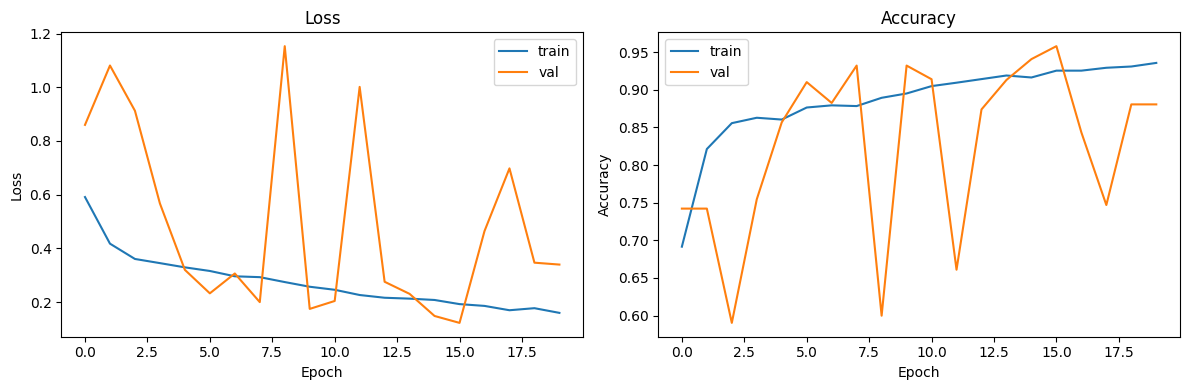

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("train_curves/combined_curves.png", dpi=150)
plt.show()

## Evaluating Model on Test Set

Training the model on test set using a confusion matrix; I have also displayed the model performance report below. 

In [40]:
from sklearn.metrics import f1_score

model = tf.keras.models.load_model(SAVE_PATH)

best_f1 = 0
best_threshold = 0.5

y_pred_probs = model.predict(test_ds)
y_true = test["label"].values

for t in np.arange(0.1, 0.9, 0.01):

    preds = (y_pred_probs > t).astype(int)

    f1 = f1_score(y_true, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(best_threshold)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
0.8899999999999996



── Test set evaluation ──


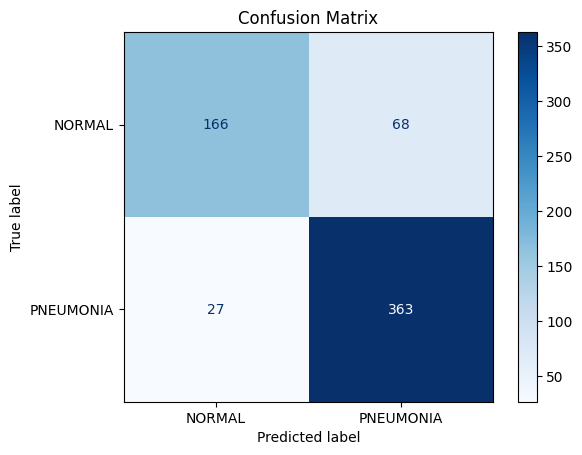

              precision    recall  f1-score   support

      NORMAL       0.86      0.71      0.78       234
   PNEUMONIA       0.84      0.93      0.88       390

    accuracy                           0.85       624
   macro avg       0.85      0.82      0.83       624
weighted avg       0.85      0.85      0.84       624



In [41]:
# matrix_label = 'Confusion_Original.png'

print("\n── Test set evaluation ──")

y_pred = (y_pred_probs >= best_threshold).astype(int).flatten()

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NORMAL", "PNEUMONIA"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.savefig('CM/combined.png', dpi=150)
plt.show()

print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"]))
